In [2]:
%matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from math import sqrt
plt.close("all")
c = 29.9792458 #speed of light in a vacuum [cm/ns]

In [3]:
def cart_len(p1,p2):
    sum = 0
    for i in range(0,len(p1)):
        sum += (p2[i] - p1[i])**2
    return sqrt(sum)

In [4]:
def time_win(anih,pl,pr):
    d_al = cart_len(pl,anih)*0.1
    d_ar = cart_len(pr,anih)*0.1
    t_l = d_al/c
    t_r = d_ar/c
    return abs(t_l-t_r)

In [5]:
def is_collin():
    pass

In [6]:
def draw_heads(x_shade,y_shade,z_shade):
    vertices = [
        [x_shade[0], y_shade[0], z_shade[0]], [x_shade[1], y_shade[0], z_shade[0]], 
        [x_shade[1], y_shade[1], z_shade[0]], [x_shade[0], y_shade[1], z_shade[0]], # Bottom 4 corners
        [x_shade[0], y_shade[0], z_shade[1]], [x_shade[1], y_shade[0], z_shade[1]], 
        [x_shade[1], y_shade[1], z_shade[1]], [x_shade[0], y_shade[1], z_shade[1]]  # Top 4 corners
    ]
    
    # 3. Connect the vertices to create the 6 flat faces of the box
    faces = [
        [vertices[0], vertices[1], vertices[2], vertices[3]], # Bottom face
        [vertices[4], vertices[5], vertices[6], vertices[7]], # Top face
        [vertices[0], vertices[1], vertices[5], vertices[4]], # Front face
        [vertices[2], vertices[3], vertices[7], vertices[6]], # Back face
        [vertices[1], vertices[2], vertices[6], vertices[5]], # Right face
        [vertices[0], vertices[3], vertices[7], vertices[4]]  # Left face
    ]
    
    # 4. Create the 3D polygon, set it to blue, and make it semi-transparent (alpha)
    shaded_box = Poly3DCollection(faces, facecolors='blue', alpha=0.3)
    return shaded_box
    

In [7]:
def calc_ctw(x1,x2,y1,y2,z1,z2):
    d = cart_len(x1,x2,y1,y2,z1,z2)*0.1 
    ctw = d/c
    return ctw
    

In [8]:
#creating an interactive 3D plot of a dual head setup with an annihilation point, and 2 interaction points  
def dh_3d_plot(x, y, z): #argument as poitns in the coordinate system of the setup
    #cartesian system of a 3d plot
    xs = x
    ys = z
    zs = y
    # creating figure
    fig = plt.figure(figsize=(10, 8))
    
    
    ax = fig.add_subplot(111, projection='3d')
    
    # creating the plot
    plot_geeks = ax.scatter(xs, ys, zs, color='black', s =50)
    ax.plot(xs,ys,zs, color='red', linewidth=2, linestyle='--')
    
    # setting title and labels
    """ax.set_title("3D plot")
    ax.set_xlabel('x-axis')
    ax.set_ylabel('y-axis')
    ax.set_zlabel('z-axis')"""
    ax.set( 
           xlabel='x [mm]', ylabel='z [mm]', zlabel='y [mm]',
           xlim=(-600, 600), ylim=(-300, 300), zlim=(-200, 200))
    
    head_l = draw_heads([-540, -370],[-250, 250],[-192, 192])
    head_r = draw_heads([370,540],[-250, 250],[-192, 192])

    #adding boxes to the ax   
    ax.add_collection3d(head_l)
    ax.add_collection3d(head_r)

    ax.xaxis.labelpad = 15
    ax.yaxis.labelpad = 15
    ax.zaxis.labelpad = 15
    # displaying the plot
    plt.savefig('3d_plot.png', dpi=300, bbox_inches='tight', pad_inches=0.5)
    plt.show()

In [9]:
def ctw(anih,pl,pr): #point of annihilation, point of interaction in left head and in right head 
    points = [anih,pl,pr]
    for point in points:
        x, y, z = zip(*points)
    ctw = time_win(anih,pl,pr)
    print(f"coincidence time window equals: {ctw}")
    dh_3d_plot(x,y,z)

coincidence time window equals: 3.686638670130532


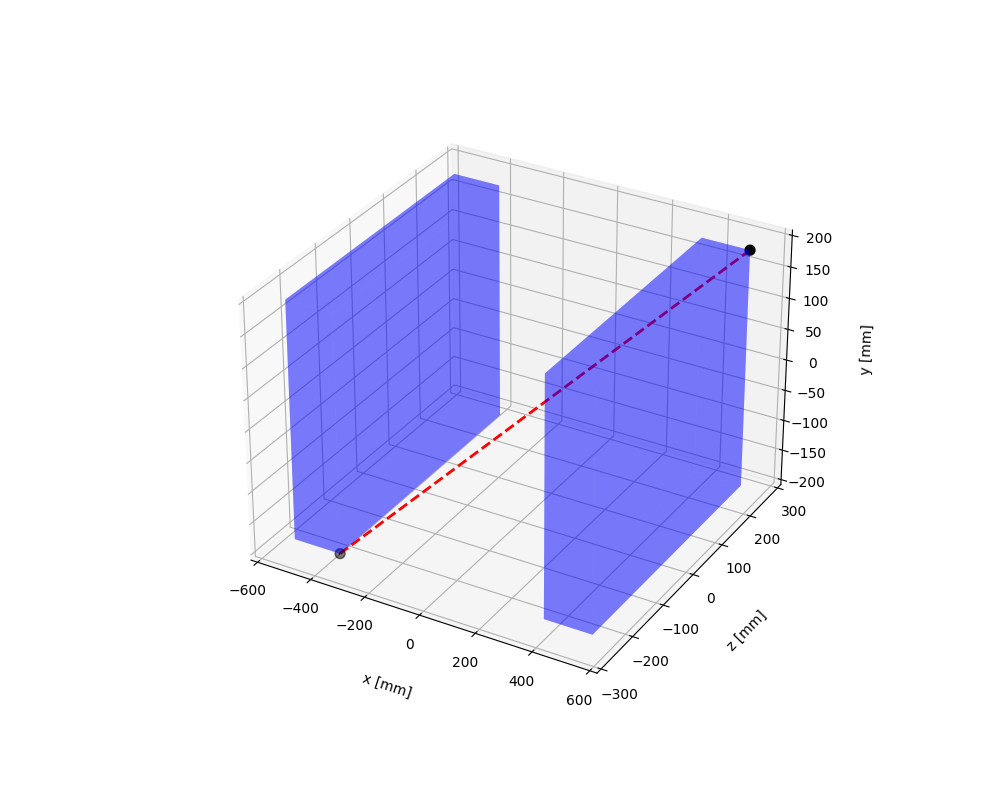

In [10]:
an = [-369,-192,-250]
int_left = [-370,-192,-250]
int_right = [540,192,250]
ctw(an,int_left,int_right)

coincidence time window equals: 0.0


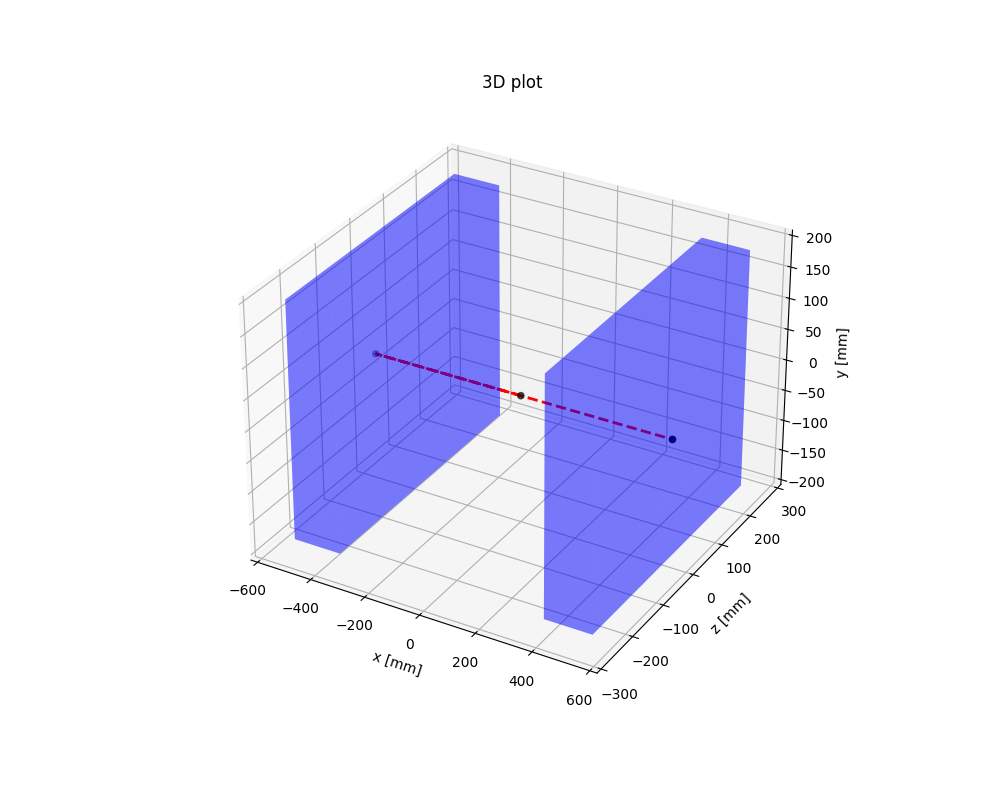

In [10]:
an = [0,0,0]
int_left = [-540,0,0]
int_right = [540,0,0]
ctw(an,int_left,int_right)

coincidence time window equals: 2.461703022562362


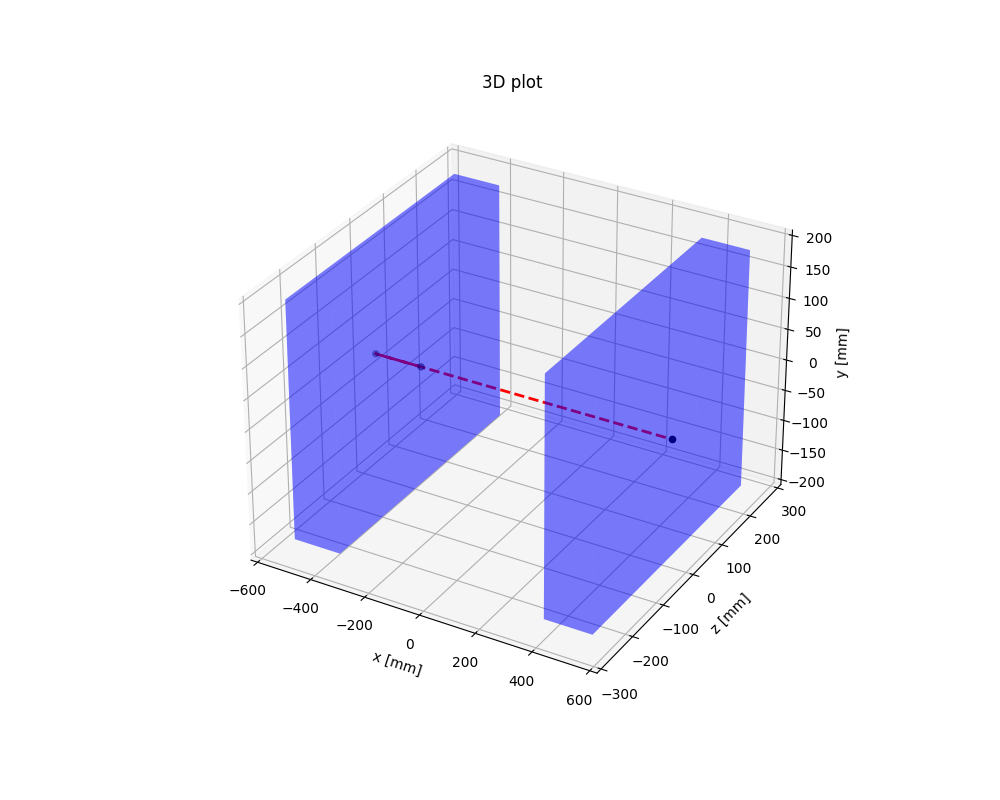

In [11]:
an = [-369,0,0]
int_left = [-540,0,0]
int_right = [540,0,0]
ctw(an,int_left,int_right)

coincidence time window equals: 3.3922043104178052


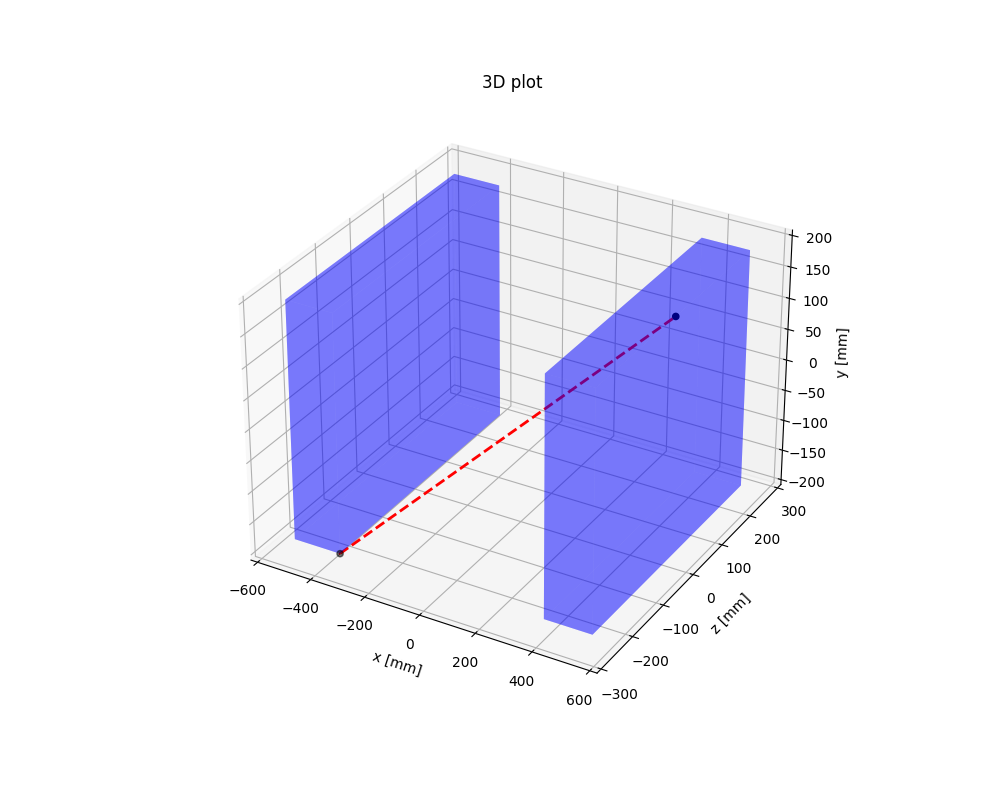

In [12]:
an = [-369,-192,-250]
int_left = [-370,-192,-250]
int_right = [540,192,0]
ctw(an,int_left,int_right)

coincidence time window equals: 3.4571904967609592


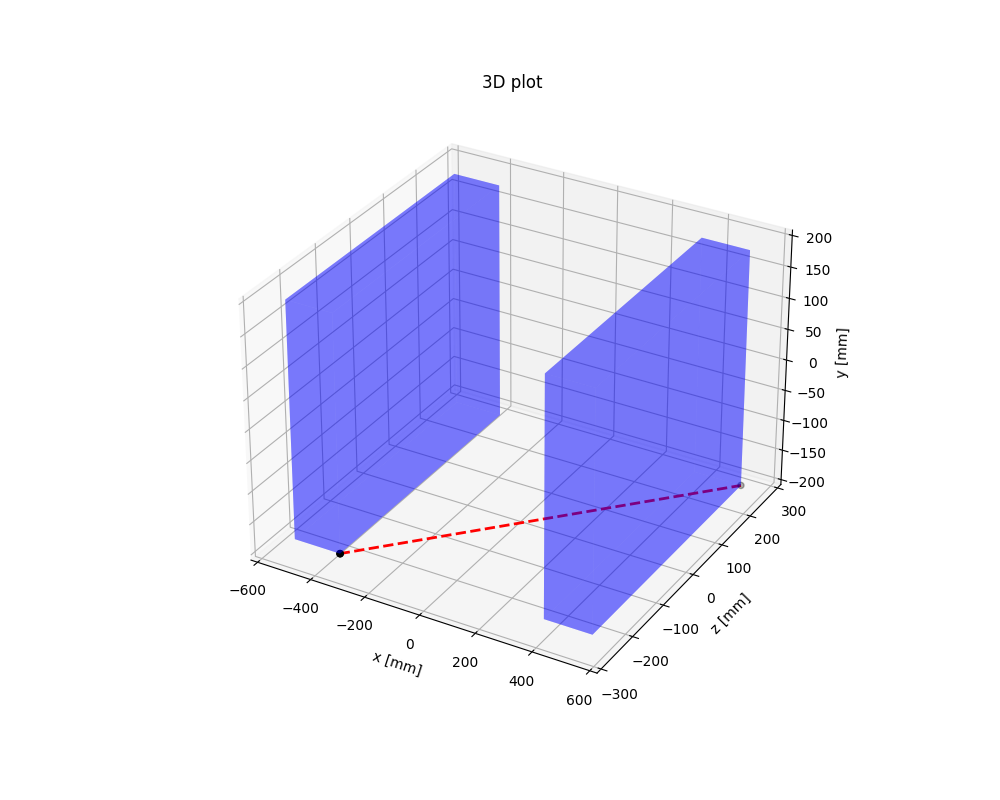

In [13]:
an = [-369,-192,-250]
int_left = [-370,-192,-250]
int_right = [540,-192,250]
ctw(an,int_left,int_right)

In [10]:
plt.close("all")